# This notebook focuses on why does params3 doesnt update the generator's parameters. To this extend, we fix the discriminator and update the generator only.

update : now it does work (ie update) when the discriminator is fixed)

In [45]:
pip install torch

Looking in indexes: https://build-nexus.prod.crto.in/repository/moab.pypi/simple
You should consider upgrading via the '/home/i.sebag/.local/share/jupyter/.python-kernel/python-kernel-47543/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import math
import scipy.stats as stats
from torch.autograd import Variable
import torch 
import scipy
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import tqdm
from tqdm import*
import torch.optim as optim
import torch.nn.functional as F
import seaborn


In [2]:
class Generator(nn.Module):
    def __init__(self, mu_q, log_sigma_q, weights):
        super().__init__()
        self.mu_q = nn.Parameter(mu_q)
        self.log_sigma_q = nn.Parameter(log_sigma_q)
        self.softmax_weights = nn.Parameter(F.softmax(weights))

    def two_modes_icdf(self, epsU):
        weights = np.exp(self.softmax_weights.detach().numpy()) #self.softmax_weights.detach().numpy() 
        mu_q = self.mu_q.detach().numpy()
        log_sigma_q = self.log_sigma_q.detach().numpy()
        if epsU < weights[0]:
            sample = stats.norm.ppf(
                epsU/weights[0], mu_q[0], math.exp(log_sigma_q[0]))
        elif epsU > weights[0]:
            sample = stats.norm.ppf(
                (epsU-weights[0])/(weights[1]), mu_q[1], math.exp(log_sigma_q[1]))
        return Variable(torch.Tensor(sample))

class Discriminator(nn.Module):
    def __init__(self, mu_k, log_sigma_k):
        super().__init__()
        self.mu_k = nn.Parameter(mu_k)
        self.log_sigma_k = nn.Parameter(log_sigma_k)

    def o2_polynomial(self, x):
        return - (x - self.mu_k)**2 / (2*torch.exp(self.log_sigma_k)**2)

In [3]:
x = np.linspace(1, 50, 10000)
x = torch.Tensor(x)
mu_true, sigma_true = torch.ones(1)*20, torch.zeros(1)*8
disc = Discriminator(mu_true, sigma_true).o2_polynomial(x)

In [4]:
disc = disc.detach().numpy()

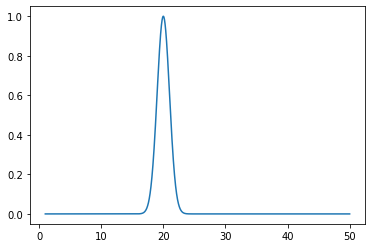

In [5]:
plt.plot(x, np.exp(disc))

In [6]:
#fix the discriminator 

In [7]:
#mu_true, sigma_true = torch.ones(1)*5, torch.ones(1)*8
#x = torch.distributions.Normal(torch.ones(100)*5, torch.ones(100)*8).sample()
#D = Discriminator(mu_true, sigma_true).o2_polynomial(x)

In [8]:
#training loop over the generator's parameters 

In [9]:
n_components = 2
weights = torch.ones(n_components, )/2
mu_q = torch.tensor([1., 1.])
log_sigma_q = torch.log(torch.ones(n_components,))

In [10]:
mu_q.requires_grad_(requires_grad=True)
log_sigma_q.requires_grad_(requires_grad=True)
weights.requires_grad_(requires_grad=True)

tensor([0.5000, 0.5000], requires_grad=True)

In [26]:
n_components = 2
weights = torch.ones(n_components, )/2
mu_q = torch.tensor([1., 3.])
log_sigma_q = torch.log(torch.ones(n_components,))

cuda = True if torch.cuda.is_available() else False
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
mu_q.requires_grad_(requires_grad=True)
log_sigma_q.requires_grad_(requires_grad=True)
weights.requires_grad_(requires_grad=True)
        
x = np.linspace(1, 50, 10000)
x = torch.Tensor(x)
mu_true, sigma_true = torch.ones(1)*5, torch.ones(1)*8
        
def train(epochs, learning_rate):

    lg = []  # loss generator
    muq = []  # muq values
    logsigmaq = []  # log sigmaq values

    generator = Generator(mu_q, log_sigma_q, weights)
    optimizer_G = optim.Adam([mu_q, log_sigma_q, weights], lr=learning_rate)
    
    for epoch in tqdm(range(epochs)):

        q = torch.distributions.Normal(mu_q, torch.exp(log_sigma_q))
        eps = np.random.uniform(0., 1., 1)
        G = generator.two_modes_icdf(eps)

        generated_data = G

        # generator's training
        optimizer_G.zero_grad()
        D = Discriminator(mu_true, sigma_true).o2_polynomial(x)
        
        loss_G = - torch.mean(D) + torch.mean(q.log_prob(generated_data))

        loss_G.backward(retain_graph=True)
        optimizer_G.step()

        lg.append(loss_G.item())

        #print('mu q : ', mu_q)
        #print('log sigma q : ', log_sigma_q)
        #muq.append(mu_q[1].item())
        #logsigmaq.append(log_sigma_q[0].item())
        
      #  print(mu_q[0].item()-torch.mean(x).item())
      #  print(mu_q[1].item()-torch.mean(x).item())

        if np.abs(mu_q[0].item()-torch.mean(x).item()) > np.abs(mu_q[1].item()-torch.mean(x).item()):
            mu_best = mu_q[1].item()
        elif np.abs(mu_q[0].item()-torch.mean(x).item()) < np.abs(mu_q[1].item()-torch.mean(x).item()):
            mu_best = mu_q[0].item()

        muq.append(mu_best)

        if np.abs(log_sigma_q[0].item() - np.log(np.sqrt(torch.var(
                x).item())) ) > log_sigma_q[1].item() - np.abs( np.log(np.sqrt(torch.var(x).item()))):
            logsigma_best = log_sigma_q[1].item()
        elif np.abs(log_sigma_q[0].item() - np.log(np.sqrt(torch.var(
                x).item())) < log_sigma_q[1].item()) - np.abs(np.log(np.sqrt(torch.var(x).item())) ):
            logsigma_best = log_sigma_q[0].item()

        logsigmaq.append(logsigma_best)


    return lg, muq, logsigmaq

In [32]:
l, muq, logsigmaq = train(2200, 1e-3)

/home/i.sebag/.local/share/jupyter/.python-kernel/python-kernel-47543/lib64/python3.6/site-packages/ipykernel_launcher.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  
100%|██████████| 2200/2200 [00:02<00:00, 930.09it/s]


In [33]:
muq

[7.572595596313477,
 7.573585033416748,
 7.574573993682861,
 7.575562477111816,
 7.576549053192139,
 7.577540397644043,
 7.5785298347473145,
 7.579514026641846,
 7.580502510070801,
 7.5814924240112305,
 7.58249044418335,
 7.583481788635254,
 7.584479331970215,
 7.5854878425598145,
 7.586484909057617,
 7.587472915649414,
 7.588465213775635,
 7.589473247528076,
 7.590485572814941,
 7.591503620147705,
 7.592514514923096,
 7.593520641326904,
 7.594514846801758,
 7.59551477432251,
 7.596515655517578,
 7.597518444061279,
 7.5985493659973145,
 7.599588394165039,
 7.600615978240967,
 7.601640224456787,
 7.602672100067139,
 7.603691577911377,
 7.604711532592773,
 7.605729103088379,
 7.606757164001465,
 7.607776641845703,
 7.608788967132568,
 7.609790802001953,
 7.610788345336914,
 7.611791610717773,
 7.612794876098633,
 7.613801956176758,
 7.614817142486572,
 7.615832805633545,
 7.616848945617676,
 7.617871284484863,
 7.618888854980469,
 7.619895935058594,
 7.620892524719238,
 7.621898651123047

In [34]:
logsigmaq

[-4.434875965118408,
 -4.435844898223877,
 -4.436812877655029,
 -4.437779426574707,
 -4.438742160797119,
 -4.439715385437012,
 -4.4406843185424805,
 -4.441642761230469,
 -4.442610263824463,
 -4.443580150604248,
 -4.444565773010254,
 -4.44553804397583,
 -4.4465227127075195,
 -4.447527885437012,
 -4.448509693145752,
 -4.449472904205322,
 -4.45044469833374,
 -4.451446056365967,
 -4.452454566955566,
 -4.4534735679626465,
 -4.454477787017822,
 -4.455471515655518,
 -4.456441879272461,
 -4.457421779632568,
 -4.458402633666992,
 -4.459386348724365,
 -4.460424423217773,
 -4.461475849151611,
 -4.462503910064697,
 -4.463522911071777,
 -4.464555740356445,
 -4.465563774108887,
 -4.4665703773498535,
 -4.467570781707764,
 -4.46859073638916,
 -4.469593524932861,
 -4.470580577850342,
 -4.471546649932861,
 -4.472502708435059,
 -4.47346830368042,
 -4.474432945251465,
 -4.475403308868408,
 -4.476388931274414,
 -4.4773736000061035,
 -4.478358745574951,
 -4.479354381561279,
 -4.480340003967285,
 -4.48130559

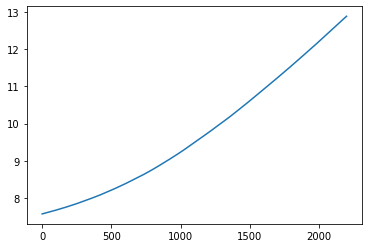

In [35]:
plt.figure()
plt.plot(muq)
#plt.plot(mu_true)
plt.show()

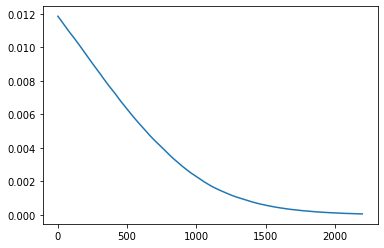

In [36]:
plt.figure()
plt.plot(np.exp(logsigmaq))
#plt.plot(sigma_true)
plt.show()

# Now let us try to see the updates when the discriminator is updated as well as the generator 

In [2]:
#make the discr a gmm
#train the gen, take the last val (at convergence), fit them into the gen and sample from the gen 

In [ ]:

def train(epochs, learning_rate, entropy=False, affine=False, uni_icdf=False, two_modes_icdf=False, gmm_logprob=False, o2=False, o4=False):

    mu_k = torch.ones(1)
    log_sigma_k = torch.ones(1)

    mu_k.requires_grad_(requires_grad=True)
    log_sigma_k.requires_grad_(requires_grad=True)

    if affine == True or uni_icdf == True:
        mu_q = torch.zeros(1)
        log_sigma_q = torch.ones(1)
        weights = torch.ones(1)

    elif two_modes_icdf == True or gmm_logprob == True:
        n_components = 2
        weights = torch.ones(n_components, )/2
        mu_q = torch.tensor([1., 14.])
        log_sigma_q = torch.log(torch.ones(n_components,))

    cuda = True if torch.cuda.is_available() else False
    Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
    mu_q.requires_grad_(requires_grad=True)
    log_sigma_q.requires_grad_(requires_grad=True)

    weights.requires_grad_(requires_grad=True)

    lg = []  # loss generator
    ld = []  # loss discriminator
    muq = []  # muq values
    muk = []  # muk values
    logsigmaq = []  # log sigmaq values
    logsigmak = []  # log sigmak values
    log_likelihood = []  # log likelohood values
    approx_log_likelihood =  []  # approx log likelihood values

    generator = Generator(mu_q, log_sigma_q, weights)
    optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate)

    discriminator = Discriminator(mu_k, log_sigma_k)
    optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate)

    for epoch in tqdm(range(epochs)):

        if entropy == True:
            q = torch.distributions.Normal(mu_q, torch.exp(log_sigma_q))

        if affine == True:
            eps = torch.distributions.Normal(
                torch.zeros(1), torch.ones(1)).sample()
            G = generator.affine(eps)

        elif uni_icdf == True:
            eps = torch.rand(1)
            G = generator.uni_icdf(eps)

        elif two_modes_icdf == True:
            #eps = torch.rand(1)
            #eps = eps.detach().numpy()
            eps = np.random.uniform(0., 1., 1)
            G = generator.two_modes_icdf(eps)

        elif gmm_logprob == True:
            eps = torch.distributions.Normal(
                torch.zeros(1), torch.ones(1)).sample()
            G = generator.gmm_logprob(eps)

        generated_data = G

        if o2 == True:
            Dx = discriminator.o2_polynomial(x)  # discriminator over real data
            # discriminator over fake data
            Df = discriminator.o2_polynomial(generated_data)

        elif o4 == True:
            Dx = discriminator.o4_polynomial(x)
            Df = discriminator.o4_polynomial(generated_data)

        # discriminator's training
        optimizer_D.zero_grad()
        loss_D = - torch.mean(Dx) + torch.mean(Df)
        loss_D.backward()
        optimizer_D.step()

        ld.append(loss_D.item())
        muk.append(mu_k.item())
        logsigmak.append(log_sigma_k.item())

        k = torch.distributions.Normal(mu_k, torch.exp(log_sigma_k))
        log_likelihood.append(torch.sum(k.log_prob(x)).item())

        if entropy == True:
            approx_log_z = torch.mean(Df - q.log_prob(generated_data))
            a = torch.sum(Dx) - len(x)*approx_log_z
            approx_log_likelihood.append(a.item())

        # generator's training
        optimizer_G.zero_grad()
        if affine == True:
            generated_data2 = generator.affine(eps)

        elif uni_icdf == True:
            generated_data2 = generator.uni_icdf(eps)

        elif two_modes_icdf == True:
            generated_data2 = generator.two_modes_icdf(eps)

        elif gmm_logprob == True:
            generated_data2 = generator.gmm_logprob(eps)

        if o2 == True:
            Dx2 = discriminator.o2_polynomial(
                x)  # discriminator over real data
            # discriminator over fake data
            Df2 = discriminator.o2_polynomial(generated_data2)

        elif o4 == True:
            Dx2 = discriminator.o4_polynomial(x)
            Df2 = discriminator.o4_polynomial(generated_data2)

        if entropy == True:
            loss_G = - torch.mean(Df2
                                  ) + torch.mean(q.log_prob(generated_data2))

        elif entropy == False:
            loss_G = - torch.mean(Df2)

        loss_G.backward()
        optimizer_G.step()

        lg.append(loss_G.item())

        if affine == True or uni_icdf == True:
            muq.append(mu_q.item())
            logsigmaq.append(log_sigma_q.item())



        elif two_modes_icdf == True or gmm_logprob == True:
            #     mu_best = torch.min(mu_q[0]-torch.mean(x), mu_q[1]-torch.mean(x))
            #     muq.append(mu_best)
            #     logsigma_best = torch.min(log_sigma_q[0] - torch.log(torch.sqrt(torch.var(
            #         x))), log_sigma_q[1] - torch.log(torch.sqrt(torch.var(x))))
            #     logsigmaq.append(logsigma_best)

            if np.abs(mu_q[0].item()-torch.mean(x).item()) > np.abs(mu_q[1].item()-torch.mean(x).item()):
                mu_best = mu_q[1].item()
            elif np.abs(mu_q[0].item()-torch.mean(x).item()) < np.abs(mu_q[1].item()-torch.mean(x).item()):
                mu_best = mu_q[0].item()

            muq.append(mu_best)

            if np.abs(log_sigma_q[0].item() - np.log(np.sqrt(torch.var(
                    x).item())) ) > log_sigma_q[1].item() - np.abs( np.log(np.sqrt(torch.var(x).item()))):
                logsigma_best = log_sigma_q[1].item()
            elif np.abs(log_sigma_q[0].item() - np.log(np.sqrt(torch.var(
                    x).item())) < log_sigma_q[1].item()) - np.abs(np.log(np.sqrt(torch.var(x).item())) ):
                logsigma_best = log_sigma_q[0].item()

            logsigmaq.append(logsigma_best)

    if entropy == True:
        return loss_G, loss_D, lg, ld, muq, muk, logsigmaq, logsigmak, log_likelihood, approx_log_likelihood, approx_log_z

    elif entropy == False:
        return loss_G, loss_D,  lg, ld, muq, muk, logsigmaq, logsigmak, log_likelihood
